# 9. 비지도 학습

**기본설정**

파이썬 3.7 이상을 요구한다.

In [1]:
import sys

assert sys.version_info >= (3, 7)

사이킷런 1.0.1 이상을 요구한다.

In [2]:
import sklearn

assert sklearn.__version__ >= "1.0.1"

다음은 이미지에 포함된 폰트 크기를 설정한다.

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

이미지 저장 경로를 설정한다.

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

## 9.1. 분류 대 군집화

**예제: 붓꽃 데이터셋 군집화**

- 붓꽃 데이터셋 불러오기

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

아래 코드는 분류와 군집화의 차이를 보여주는 그림을 그린다.

- 왼편: 각 샘플이 속하는 품종에 따른 분류
- 오른편: 지정된 기준에 따라 비슷한 샘플들끼리 그룹짓기

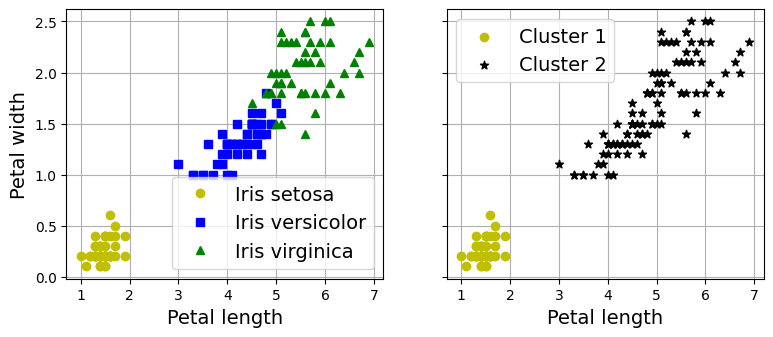

In [6]:
plt.figure(figsize=(9, 3.5))

# 왼쪽 그림(분류)
plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

# 오른쪽 그림(군집)
plt.subplot(122)
plt.scatter(X[y==0, 2], X[y==0, 3], c="y", marker="o", label="Cluster 1")
plt.scatter(X[(y==1) | (y==2), 2], X[(y==1) | (y==2), 3], c="k", marker="*", label="Cluster 2")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()
plt.legend()

plt.show()

**가우스 혼합 모델 활용**

꽃잎 길이와 너비만으로는 두 개의 군집으로만 구분이 가능해 보인다. 하지만 꽃잎의 길이와 너비와 더불어 꽃받침의 길이와 너비까지 포함한 네 개의 특성을 모두 사용하여 후반부에서 가우스 혼합 모델을 이용하여 세 개의 군집으로 나눌 수 있다.

- 3개의 군집 지정: 가우스 혼합 모델 이용

In [7]:
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture

y_pred = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)

`y_pred`를 확인하면 세토사는 1번 군집,
버시컬러와 버지니카 거의 대부분 2번과 0번 군집으로 구분된다.
일부 버시컬러와 버지니카 일부 샘플은 혼동되기도 한다.

In [8]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

- 군집 번호를 해당 군집에 가장 많이 포함된 품종 번호로 변경.
    `stats.mode()` 함수는 해당 어레이의 최빈값(mode)과 최빈값이 몇 번 사용되었는지 확인해줌.
    최종 결과는 다음과 같다.

    - 2번 인덱스 군집: 세토사(0)가 제일 많음.
    - 0번 인덱스 군집: 버시컬러(1)가 제일 많음.
    - 1번 인덱스 군집: 버지니카(2)가 제일 많음.

In [9]:
mapping = {}
for class_id in np.unique(y):
    mode, _ = stats.mode(y_pred[y==class_id], keepdims=True)  # 첫재 항목이 최빈값, 둘째 항목이 빈도수
    mapping[mode[0]] = class_id

mapping

{np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(0): np.int64(2)}

`mapping`을 이용하여 `y_pred`를 변환하면 세토사는 0,
버시컬러와 버지니카 거의 대부분 1과 2로 변환된다.
일부 버시컬러와 버지니카 일부 샘플은 혼동되기도 한다.

In [10]:
# 군집 번호를 해당 군집에 가장 많이 포함된 클래스로 변환
y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

- 군집화 정확도: 군집 인덱스를 품종 인덱스로 변경한 후에 군집화의 측정된 정확도는 96.7%

In [11]:
(y_pred==y).sum() / len(y_pred)

np.float64(0.9666666666666667)

- 군집별 산점도 그리기: 변환된 `y_pred`를 이용하여 군집별 산점도를 그리면 다음과 같이
군집화가 매우 잘 진행되었음을 확인할 수 있다.

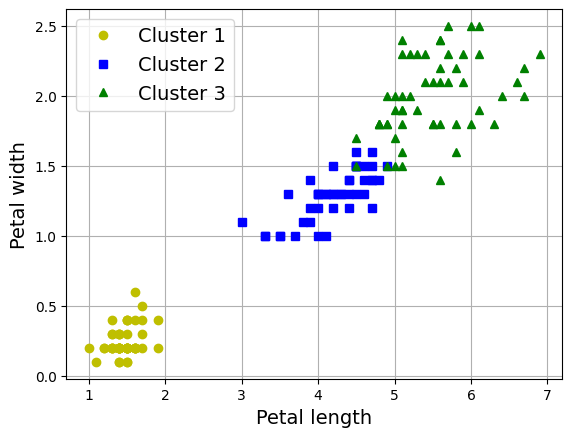

In [12]:

plt.plot(X[y_pred==0, 2], X[y_pred==0, 3], "yo", label="Cluster 1")
plt.plot(X[y_pred==1, 2], X[y_pred==1, 3], "bs", label="Cluster 2")
plt.plot(X[y_pred==2, 2], X[y_pred==2, 3], "g^", label="Cluster 3")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.grid()
plt.show()

## 9.2. k-평균

**데이터셋 준비**

먼저 2,000개의 데이터 샘플을 생성한다.
`make_blobls()` 함수는 지정된 센터와 표준편차를 이용하여
지정된 수 만큼 원형 데이터셋을 생성한다.
즉, 표준편차는 원의 반지름 역할을 수행한다.
각 군집에 포함된 데이터샘플의 수는 거의 동일하게 구분된다.
따라서 표준편차가 크면 그만큼 데이터가 넓게 분포된다.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,
                  random_state=7)

훈련셋 `X`의 산점도를 그리면 다음과 같다.

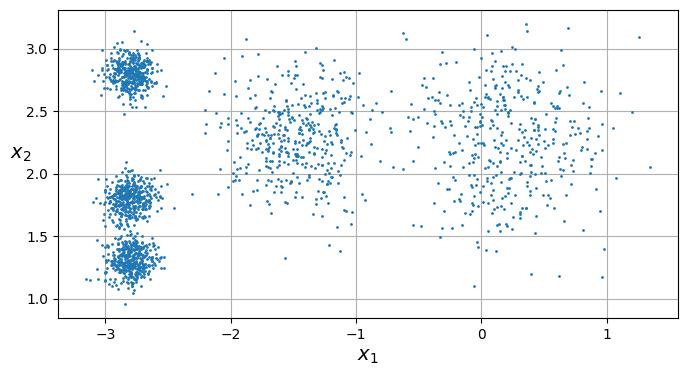

In [14]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()
# save_fig("blobs_plot")
plt.show()

`y` 는 각 데이터 샘플의 군집 번호(레이블)를 가리키지만 비지도 학습에서는 일반적으로 활용되지 않는다.

**k-평균 모델 훈련**

In [15]:
k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)

y_pred = kmeans.fit_predict(X)

각 훈련 샘플이 속하는 군집은 0, 1, 2, 3, 4 의 인덱스로 지정된다.
인덱스가 레이블이 아님에 주의하라.

In [16]:
y_pred

array([0, 0, 4, ..., 3, 1, 0], dtype=int32)

- `labels_` 속성: 군집 정보 저장

In [17]:
kmeans.labels_ is y_pred

True

- `cluster_centers_` 속성: 5개 군집의 센트로이드의 좌표

In [18]:
kmeans.cluster_centers_

array([[-2.80214068,  1.55162671],
       [ 0.08703534,  2.58438091],
       [-1.46869323,  2.28214236],
       [-2.79290307,  2.79641063],
       [ 0.31332823,  1.96822352]])

- `predict()` 메서드: 새로운 데이터에 대한 군집 예측



In [19]:
import numpy as np

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([4, 4, 3, 3], dtype=int32)

**보로노이 다이어그램**

군집을 나누는 결정경계를 그리면 보로노이 다이어그램이 생성된다.

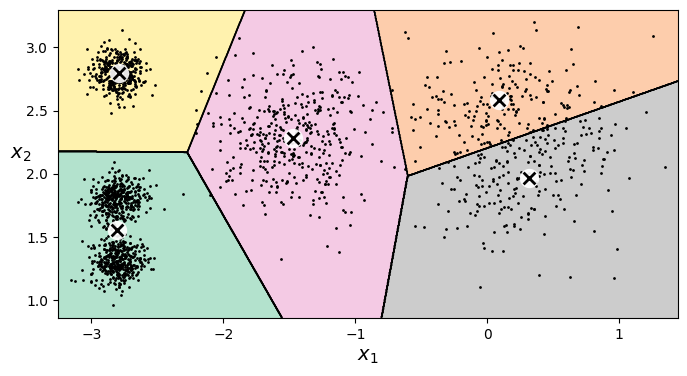

In [20]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    # 바탕 그리기
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")

    # 결정 경계 그리기
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')

    # 훈련 데이터셋과 센트로이드 그리기
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)

plt.show()

### 9.2.1. k-평균 알고리즘

### 9.2.2. 센트로이드 초기화 문제 해결 방안

**관성**

비지도 학습인 k-평균 모델의 성능을 **관성**(inertia)을 이용하여 측정한다.

* 관성: 각 훈련 샘플과 가장 가까운 센트로이드 사이의 거리를 모두 합한 값
* `inertia_` 속성에 저장됨.

좋은 모델의 관성은 낮다.

In [21]:
kmeans.inertia_

219.42800073647598

`score()` 메서드는 관성의 음숫값을 반환한다.
이유는 "더 높은 점수가 더 좋다"의 원칙을 따라야 하기 때문이다.

In [22]:
kmeans.score(X)

-219.428000736476

**미니배치 k-평균**

사이킷런의 `MiniBatchKMeans` 모델은 미니배치 학습을 지원한다.

* `batch_size=100`: 배치 크기 지정. 기본값은 100.

In [23]:
from sklearn.cluster import MiniBatchKMeans

# batch: 한 번에 처리할 데이터의 양
minibatch_kmeans = MiniBatchKMeans(n_init=10, n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5, n_init=10, random_state=42)

관성이 아주 조금 커졌지만 거의 유사하다.

In [24]:
minibatch_kmeans.inertia_

211.66282023647622

**`MiniBatchKMeans` 와 `memmap` 클래스**

[8장 차원 축소](https://codingalzi.github.io/handson-ml3/dimensionality_reduction.html)의
주성분 분석에서 소개한 넘파이 `memmap` 클래스를 이용하여 MNIST 데이터셋을
대상으로 미니배치 k-평균 모델을 훈련해보자.

먼저 MNIST 데이터셋을 불러온다.

In [25]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")

훈련셋와 테스트 세트로 구분한다.

In [26]:
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

`memmap` 객체로 지정한다.

In [27]:
filename = "my_mnist.mmap"
X_memmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_memmap[:] = X_train
X_memmap.flush()

`MiniBatchKMeans` 모델을 훈련한다.

In [28]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_init=10, n_clusters=10, batch_size=10,
                                   random_state=42)
minibatch_kmeans.fit(X_memmap)

MiniBatchKMeans(batch_size=10, n_clusters=10, n_init=10, random_state=42)

미니배치 k-평균 알고리즘이 일반 k-평균 알고림즘 보다 훨씬 빠르다.
반면에 성능은 조금 떨어진다.

### 9.2.3. 최적의 군집수

**방법 1: 관성과 군집수**

실제로 군집수가 많아질 수록 관성은 줄어든다.
이유는 센트로이드 수가 늘어날 수록 각 샘플과 센트로이드 사이의 거리는 줄어들 수밖에 없기 때문이다.
아래 코드가 이 사실을 잘 보여준다.

* $k$가 1부터 9까지 변하는 동안 훈련된 모델의 관성을 측정한다.

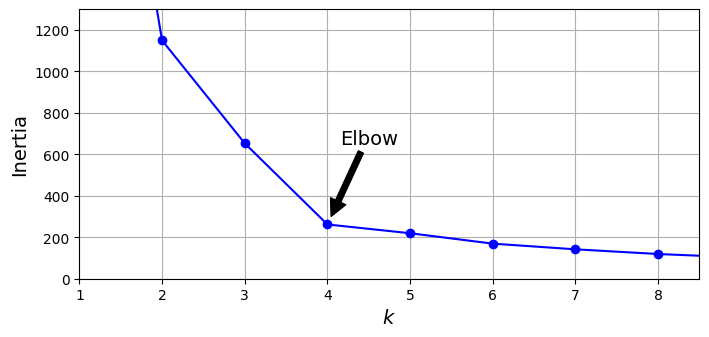

In [29]:
kmeans_per_k = [KMeans(n_init=10, n_clusters=k, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1300])
plt.grid()
# save_fig("inertia_vs_k_plot")
plt.show()

팔꿈치(elbow)에 해당하는 위치인 $k=4$, 즉, 네 개의 군집이 좋아 보인다.
군집이 네 개보다 작으면 별로이고, 4개보다 많아도 별로 좋아지지 않아 보인다.
하지만 아래 그림에서 볼 수 있듯이 왼쪽 하단 두 개의 군집이 하나의 군집으로 처리되기 때문이다.
그럼에도 불구하고 꽤 좋은 군집화 모델임엔 틀림없다.

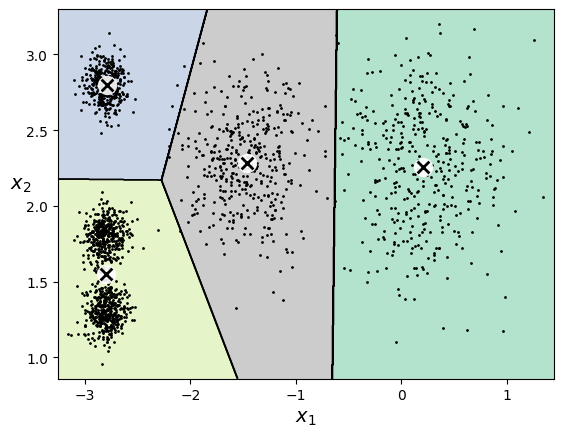

In [30]:
plot_decision_boundaries(kmeans_per_k[4 - 1], X)
plt.show()

**방법 2: 실루엣 점수와 군집수**

실루엣 점수는 `silhouette_score()` 가 계산한다.

In [31]:
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_)

np.float64(0.6353422668284151)

아래 코드는 군집수가 증가할 때 실루엣 점수의 변화를 보여준다.
k=4가 여전히 매우 좋아 보인다.
하지만 관성의 경우와는 달리 k=5도 역시 꽤 좋다는 것을 알 수 있다.

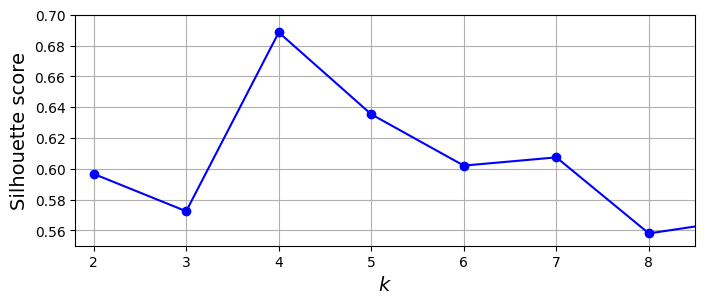

In [32]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()

plt.show()

**방법 3: 실루엣 다이어그램과 군집수**

군집별로 각 샘플의 실루엣 계수를 오름차순으로 정렬한 그래프인
**실루엣 다이어그램**(silhouette diagram)이 보다 많은 정보를 전달한다.

아래 코드에서 사용된 눈금 위치 지정자 `FixedLocator`와 눈금 형식 지정자 `FixedFormatter`는
지정된 위치에 원하는 눈금을 작성할 때 사용된다.
자세한 사용법은 아래 링크를 참고한다.

- 눈금 위치 지정자: https://matplotlib.org/stable/gallery/ticks/tick-locators.html
- 눈금 형식 지정자: https://matplotlib.org/stable/gallery/ticks/tick-formatters.html

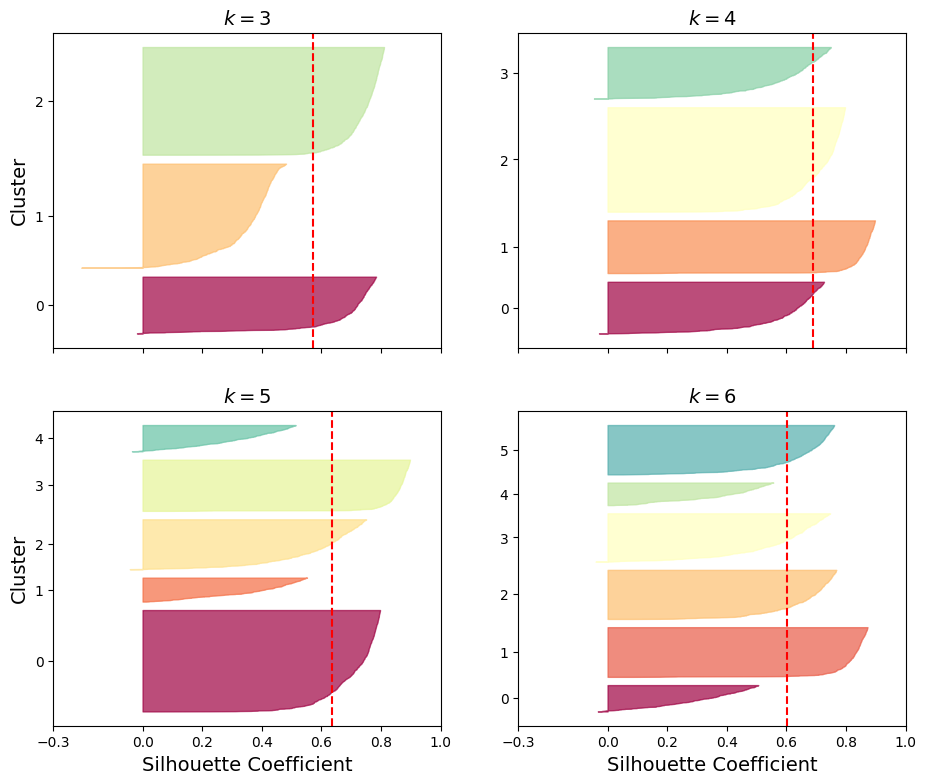

In [33]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

# 군집수에 따른 실루엣 다이어그램 그리기
for k in (3, 4, 5, 6):                                                    # 군집 수: 3, 4, 5, 6
    plt.subplot(2, 2, k - 2)                                              # 2행 2열의 k번째 그래프

    y_pred = kmeans_per_k[k - 1].labels_                                  # k번째 군집의 레이블
    silhouette_coefficients = silhouette_samples(X, y_pred)               # 실루엣 계수

    padding = len(X) // 30                                                # 칼날 간격
    pos = padding                                                         # 칼날 위치
    ticks = []                                                            # y-축 눈금 위치

    # 군집별 실루엣 계수 그리기
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]                     # i번째 군집의 실루엣 계수
        coeffs.sort()

        color = plt.cm.Spectral(i / k)                                    # i번째 군집 칼날 색상
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,   # i번째 군집 칼날 그리기
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)                              # i번째 군집 칼날 눈금 위치
        pos += len(coeffs) + padding                                      # i+1번째 군집 칼날 위치

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))                # y-축 눈금
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))         # y-축 눈금 레이블
    plt.gca().set_xticks([-0.3, 0, 0.2, 0.4, 0.6, 0.8, 1])                # x-축 눈금

    if k in (3, 5):                                                       # y-축 레이블
        plt.ylabel("Cluster")

    if k in (5, 6):                                                       # x-축 레이블
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)                                # x-축 레이블 없애기

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")  # 실루엣 점수 빨강 파선
    plt.title(f"$k={k}$")

plt.show()

$k=5$인 경우가 가장 좋아 보인다.
이유는 모든 군집이 거의 비슷한 크기이고, 모든 군집의 칼날이 실루엣 점수(빨강 파선)넘어서고 있기 때문이다.

### 9.2.4. k-평균의 한계

k-평균의 가장 큰 단점은 최적의 군집수를 확인하기 위해 알고리즘을 여러 번 실행해야 한다는 점이다.
또한 군집의 크기와 밀도가 서로 다른거나 원형이 아닌 경우 k-평균 모델이 제대로 작동하지 않을 수 있다.

아래 코드는 타원 모양의 군집으로 이루어진 데이터셋을 생성한다.

In [34]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42) # 원형 모양의 2개의 군집
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))                          # 타원 모양으로 변형. 공분산 행렬 지정

X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)                  # 원형 모양의 1개의 군집
X2 = X2 + [6, -8]                                                               # 중심 이동

X = np.r_[X1, X2]
y = np.r_[y1, y2]

산점도를 그리면 아래와 같다.

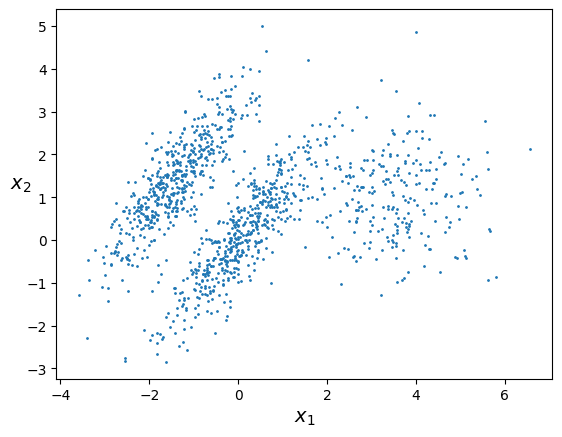

In [35]:
plot_clusters(X)

알고 있는 센트로이드 정보를 이용하여 좋은 k-평균 모델을 훈련하더라도
아주 좋은 군집화는 어렵다.

In [36]:
kmeans_good = KMeans(n_clusters=3,
                     init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]),
                     n_init=1, random_state=42)
kmeans_good.fit(X)

KMeans(init=array([[-1.5,  2.5],
       [ 0.5,  0. ],
       [ 4. ,  0. ]]),
       n_clusters=3, n_init=1, random_state=42)

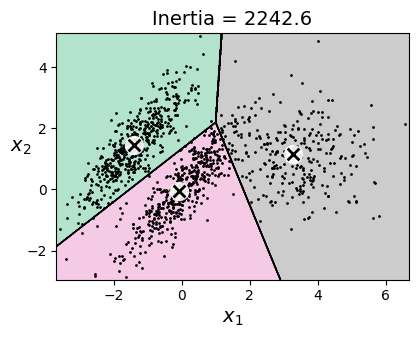

In [37]:
plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title(f"Inertia = {kmeans_good.inertia_:.1f}")

plt.show()

센트로이드를 직접 찾으라 하면 더더욱 나쁜 군집화가 생성된다.

In [38]:
kmeans_bad = KMeans(n_init=10, n_clusters=3, random_state=42)
kmeans_bad.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

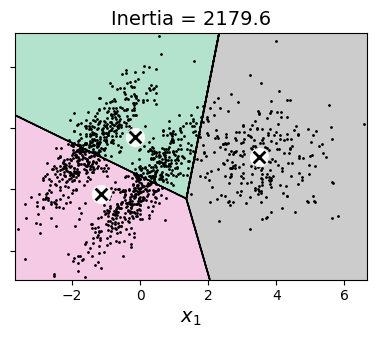

In [39]:
plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title(f"Inertia = {kmeans_bad.inertia_:.1f}")

plt.show()

## 9.3. 군집화 활용

### 9.3.1. 이미지 분할: 색상 분할

이미지 색상 분할은 유사한 색상을 동일한 군집에 연결하는 기법을 의미한다.
색상 분할 과정을 살펴보기 위해 무당벌레 이미지를 하나 다운로드한다.

In [40]:
import urllib.request

homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
filename = "ladybug.png"
filepath = IMAGES_PATH / filename
if not filepath.is_file():
    print("Downloading", filename)
    url = f"{homl3_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

다운로드된 이미지는 `533 x 800` 픽셀 크기의 칼라 사진이다.

In [41]:
import PIL # pip install Pillow

image = np.asarray(PIL.Image.open(filepath))
image.shape

(533, 800, 3)

k-평균 모델 훈련을 위해 이미지 픽셀을 일차원으로 변환한다.
즉, `(533, 800, 3)` 모양의 어레이를 `(426400, 3)` 모양의 2차원 어레이로 변환한다.

**참고:** `533 * 800 = 426,400`

In [42]:
X = image.reshape(-1, 3)
X.shape

(426400, 3)

아래 코드는 8개의 군집을 이용한 색상 분할과정을 보여준다.
먼저, k-평균 모델을 설정한다.

- `n_clusters=8`: 8개의 군집 사용

In [43]:
kmeans = KMeans(n_init=10, n_clusters=8, random_state=42).fit(X)

각 훈련 샘플에 대한 레이블(`kmeans.labels_`)을 이용하여 군집별 센트로이드의 색상으로 통일시킨다.
이를 위해 넘파이 어레이에 대한 팬시 인덱싱을 활용한다.

In [44]:
segmented_img = kmeans.cluster_centers_[kmeans.labels_]

이미지를 원래의 크기로 다시 변환한다.

In [45]:
segmented_img = segmented_img.reshape(image.shape)

아래 코드는 앞서 설명한 방식을 다양한 군집수에 대해 적용한 결과를 비교할 수 있는 그림을 보여준다.

In [46]:
n_colors = (10, 8, 6, 4, 2)  # 군집수
segmented_imgs = []          # 군집수 별 이미지 모음

for n_clusters in n_colors:
    kmeans = KMeans(n_init=10, n_clusters=n_clusters, random_state=42).fit(X) # k-평균 군집화
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]                       # 군집별 색상을 센트로이드 색상으로 통일
    segmented_imgs.append(segmented_img.reshape(image.shape))                     # 이미지 모음에 추가

- 원본 이미지와 군집화를 활용한 5개의 이미지 비교
    - 군집수가 적어질 수록 작은 무당벌레의 색상을 다른 군집과 연결하기에 무당벌레 색상이 점차 사라짐.

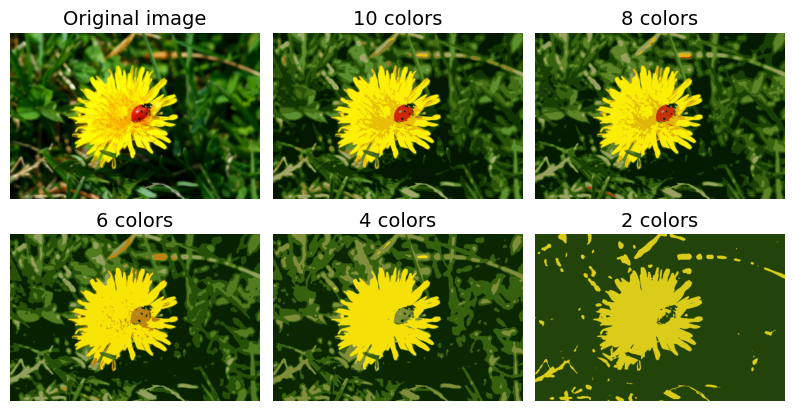

In [47]:
plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1) # 이미지 간격 조정

# 원본 이미지
plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

# 색상 분할된 이미지 5개
for idx, n_clusters in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

plt.show()

### 9.3.2. 준지도 학습

준지도학습은 약간의 레이블이 있는 샘플이 있고 대부분의 샘플엔 레이블이 없는 데이터셋에 대한
지도학습 기법이다.
준지도학습 설명을 위해 미니 MNIST 데이터셋을 이용한다.

**미니 MNIST 데이터셋**

8×8 모양의 1,797 개의 흑백 숫자 손글씨 사진으로 구성된 데이터셋을 다운로드 한 후에
훈련셋과 테스트셋으로 구분한다.

- 훈련셋 크기: 1400
- 테스트셋 크기: 397

In [48]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [49]:
print(X_train.shape, y_digits.shape)
print(X_train[0])

(1400, 64) (1797,)
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


먼저 50개의 샘플만을 대상으로 로지스틱 회귀모델을 훈련하면
정확도 평균값이 74.81% 정도로 낮게 나온다.
이유는 훈련셋이 작아서 훈련이 제대로 되지 않기 때문이다.

In [50]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

LogisticRegression(max_iter=10000)

정확도는 74.81% 정도

In [51]:
log_reg.score(X_test, y_test)

0.7581863979848866

훈련셋 전체를 사용하면 90.68% 의 정확도가 나온다.

In [52]:
log_reg_full = LogisticRegression(max_iter=10_000)
log_reg_full.fit(X_train, y_train)
log_reg_full.score(X_test, y_test)

0.9093198992443325

**비교 대상 2: 대표 이미지 50개 활용 훈련**

50 개의 군집으로 군집화한 뒤에 각 군집의 센트로이드에 가장 가까운 이미지 50개를 대상으로
훈련했을 때 로지스틱 회귀 모델의 성능을 확인해보자.

**참고**: 센트로이드에 가장 가까운 이미지를 **대표 이미지**라 부른다.

먼저 50개의 군집으로 나눈 후 변환한다.

In [53]:
k = 50
kmeans = KMeans(n_init=10, n_clusters=k, random_state=42)

훈련된 k-평균 모델의 `fit_transform()` 메서드는 주어진 샘플을
찾아진 센트로이드와의 거리로 구성된 어레이를 계산한다.
여기서는 1400개의 훈련 샘플에 대해 50개의 센트로이드와의 거리를 계산한 어레이를
생성한다.

In [54]:
X_digits_dist = kmeans.fit_transform(X_train)

따라서 변환된 어레이는 50개의 특성을 갖는다.

In [55]:
X_digits_dist

array([[39.2013243 , 51.61166593, 35.78092988, ..., 38.38114439,
        50.23366329, 39.12819457],
       [38.04484845, 32.68742517, 49.74639198, ..., 49.57935301,
        46.33618043, 40.98059968],
       [39.89248668, 41.45574598, 52.89107126, ..., 45.0884618 ,
        45.41881992, 38.78359351],
       ...,
       [47.70359228, 31.996892  , 53.95358402, ..., 51.32081966,
        58.66979688, 48.15773173],
       [46.20208562, 31.35143073, 53.34513581, ..., 51.42509909,
        58.40766568, 47.54535798],
       [35.79679446, 44.83906598, 47.16070489, ..., 47.4428765 ,
        54.8295814 , 39.67310178]])

In [56]:
X_digits_dist.shape

(1400, 50)

대표 이미지 훈련셋은 50개의 센트로이드에 가장 가까운 50개의 샘플로 구성된다.
변환된 데이터셋의 50개 특성 각각에 대해 가장 가까운 거리에 있는 샘플 50개를 선택해서
대표 이미지 훈련셋을 생성한다.

In [57]:
representative_digit_idx = X_digits_dist.argmin(axis=0)     # 각 센트로이드에 가장 가까운 이미지의 인덱스
X_representative_digits = X_train[representative_digit_idx] # 각 센트로이드에 가장 가까운 이미지

선정된 50개의 대표 이미지에 포함된 숫자는 다음과 같다.

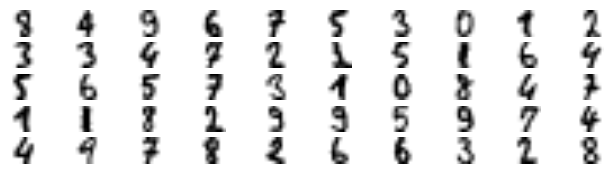

In [58]:
plt.figure(figsize=(8, 2))

for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

plt.show()

In [59]:
y_representative_digits = y_train[representative_digit_idx]
y_representative_digits

array([8, 4, 9, 6, 7, 5, 3, 0, 1, 2, 3, 3, 4, 7, 2, 1, 5, 1, 6, 4, 5, 6,
       5, 7, 3, 1, 0, 8, 4, 7, 1, 1, 8, 2, 9, 9, 5, 9, 7, 4, 4, 9, 7, 8,
       2, 6, 6, 3, 2, 8])

50개의 대표 이미지를 이용하여 로지스틱 회귀 모델을 훈련시킨 결과 성능이 84.9% 정도로 좋아졌다.
이를 통해 무작위로 선정된 샘플의 레이블을 이용하는 것 보다 군집화를 이용하여 대표 샘플을
선정한 후에 학습하면 보다 좋은 성능의 모델이 생성됨을 확인하였다.

In [60]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8387909319899244

### 레이블 전파

**비교 대상 3: 대표 이미지 레이블 전파 후 훈련**

동일한 군집에 속하는 샘플의 레이블을 대표 이미지의 레이블로 지정하는 **레이블 전파** 방식을
활용할 때의 성능을 확인해보자.
아래 코드는 군집별로 샘플의 레이블을 대표 이미지의 레이블로 지정한다.

In [61]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)              # 레이블 전파용 빈 배열

# 군집별로 대표 이미지의 레이블 전파
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

50개가 아니라 전체 훈련셋에 대해 모든 샘플에 대해 동일한 군집의 대표 이미지의 레이블을
할당한 다음에 훈련하면 성능이 89.4% 정도 까지 향상된다.

In [62]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train, y_train_propagated)

log_reg.score(X_test, y_test)

0.8589420654911839

**비교 대상 4: 이상치 제거 후 훈련**

군집 전체에 레이블을 전파하면 이상치 등에 대한 레이블 전파도 이루어지기에 모델의 성능을
약화시킬 수 있다.
따라서 군집별로 센트로이드에서 가장 먼 샘플 1%를 제외시키고 훈련시켜 보자.

아래 코드는 각 샘플에 대해 해당 샘플이 속한 군집 센트로이드까지의 거리를 확인한 후에
군집별로 센트로이드 근접도가 하위 1% 샘플의 거리를 -1로 지정한다.

In [63]:
percentile_closest = 99 # 각 군집의 센트로이드 근접도 기준을 99% 백분위수로 지정

# 샘플별로 샘플이 포함된 군집의 센트로이드와의 거리 계산
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]

# 군집별로 센트로이드 근접도가 하위 1%의 샘플과 센트로이드의 거리를 -1로 지정
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

아래 코드는 군집별로 센트로이드 근접도가 하위 1% 안에 드는 샘플은 훈련셋에서 제외시킨다.

In [64]:
partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

선정된 샘플만을 이용하여 로지스틱 회귀 모델을 훈련한 후에 성능을 평가하면,
91% 정도까지 향상한다.

In [65]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8564231738035264

센트로이드 근접도가 하위 1% 인 샘플들을 제외하면 전파된 레이블의 정확도는 97.56%에 달한다.

In [66]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

np.float64(0.9548148148148148)

## 9.4. DBSCAN

**초승달 데이터셋 준비**

In [67]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

**DBSCAN 모델 훈련**

- $\varepsilon$-이웃 반경이 0.05로 작은 경우

기계 학습 및 클러스터링 알고리즘의 맥락에서 ε(엡실론)은 점들이 이웃으로 간주되는 반경 또는 거리 임계값을 나타내는 매개변수로 자주 사용됩니다. 이 매개변수는 특히 DBSCAN(노이즈가 있는 응용 프로그램의 밀도 기반 공간 클러스터링)과 같은 알고리즘과 관련이 있습니다. 특히 DBSCAN의 경우: - **ε(엡실론):** 이 매개변수는 데이터 포인트 주위의 반경을 결정합니다. 이 반경 내에 최소한 "MinPoints"개의 데이터 포인트가 있는 경우 해당 포인트는 DBSCAN에서 "핵심 포인트"로 간주

In [68]:
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

군집이 2개보다 훨씬 많다.

In [69]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5])

- `core_sample_indices_` 속성: 핵심 샘플 인덱스 저장

In [70]:
dbscan.core_sample_indices_[:10]

array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13])

- `components_` 속성: 핵심 샘플 저장

In [71]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]])

아래 `plot_dbscan()` 함수는 DBSCAN 모델 훈련 결과를 그린다.

In [72]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

$\varepsilon$-이웃의 반경이 0.05인 경우(왼쪽)와 0.2인 경우(오른쪽)의 차이를 확인할 수 있다.

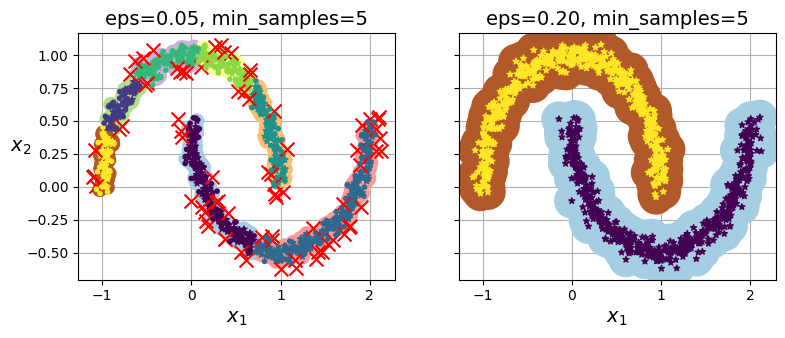

In [73]:
dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

# save_fig("dbscan_plot")
plt.show()

**DBSCAN과 예측**

DBSCAN 모델은 `predict()` 메서드가 없기에 새로운 샘플에 대한 예측을 할 수 없다.
하지만 다른 분류 모델과 연동하면 훌륭함 분류기를 생성할 수 있다.

설명을 위해 `eps=0.2`, `min_samples=5`인 모델을 재활용한다.

In [74]:
dbscan = dbscan2

군집기가 찾아낸 핵심 샘플만을 이용하여 지도 학습 분류기를 훈련시킨다.
분류기는 k-최근접 이웃 분류기 `KNeighborsClassifier`를 이용한다.

- 훈련셋: 핵심 샘플(`dbscan.components_`)
- 레이블: 핵심 샘플의 군집(`dbscan.labels_[dbscan.core_sample_indices_]`)

In [75]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50) # k-최근접 이웃 분류기
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_]) #

KNeighborsClassifier(n_neighbors=50)

이제 새로운 데이터 샘플에 대한 예측을 할 수 있다.

In [76]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

각각의 군집에 속할 확률을 확인할 수도 있다.

In [77]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

아래 코드는 군집의 결정경계와 새로운 샘플(+ 기호)에 대한 예측값을 보여준다.

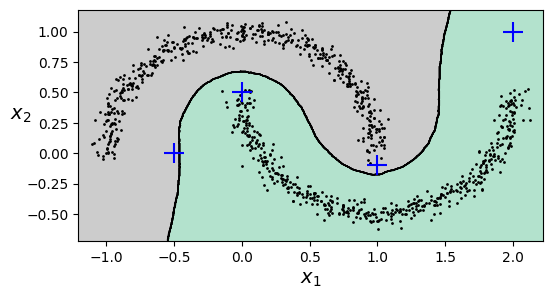

In [78]:
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
plt.show()

그런데 각 군집으로 멀리 떨어져 있는 두 개의 샘플은 이상치로 처리하는 게 보다 좋다.
아래 코드를 두 샘플의 예측값을 -1로 지정한다.

In [79]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1) # 가장 가까운 훈련셋 샘플 하나씩 선택
y_pred = dbscan.labels_[y_pred_idx]                       # 선택된 훈련셋 샘플과 동일한 군집으로 지정
y_pred[y_dist > 0.2] = -1                                 # 가까운 훈련셋 샘플과의 거리가 0.2보다 크면 이상치로 지정
y_pred.ravel()

array([-1,  0,  1, -1])

아래 그림에서 이상치로 지정된 두 개의 샘플을 빨강 동그라미로 표시했다.

<div align="center"><img src="https://raw.githubusercontent.com/codingalzi/handson-ml3/master/jupyter-book/imgs/ch09/homl09-17a.png" width="450"/></div>

## 9.5 가우스 혼합 모델

앞서 사용한 데이터셋 다시 활용

In [80]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

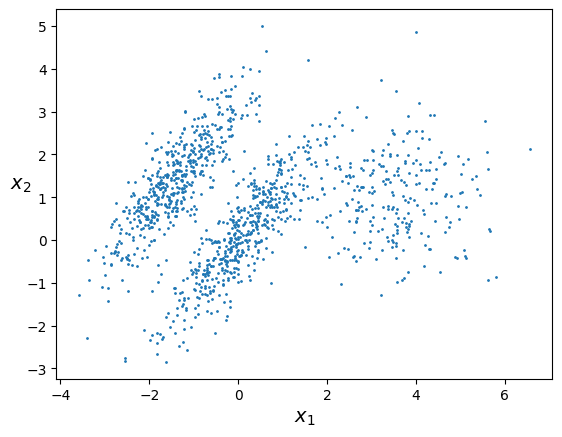

In [81]:
plot_clusters(X)

### 9.5.1. GMM 활용

가우스 혼합 모델을 위 데이터셋을 이용하여 훈련한다.

In [82]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

- 군집별 가중치(군집별 샘플 비율)

In [83]:
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

- 군집별 평균값

In [84]:
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

- 군집별 공분산

In [85]:
gm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

- 군집화 성공 여부

In [86]:
gm.converged_

True

- 군집화 성공에 필요한 초기화 횟수

In [87]:
gm.n_iter_

4

- 하드 군집화: 새로운 샘플에 대한 군집 예측

In [88]:
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1])

- 소프트 군집화: 새로운 샘플에 대해 각 군집에 속할 상대적 확률 계산

In [89]:
gm.predict_proba(X).round(3)

array([[0.   , 0.023, 0.977],
       [0.001, 0.016, 0.983],
       [1.   , 0.   , 0.   ],
       ...,
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ]])

**생성 모델**

가우스 혼합 모델은 생성 모델이다.
즉, 새로운 데이터 샘플을 군집 레이블과 함께 생성할 수 있다.
아래 코드는 6개의 새로운 샘플을 군집 정보와 함께 생성한다.

In [90]:
X_new, y_new = gm.sample(6)
X_new

array([[-2.32491052,  1.04752548],
       [-1.16654983,  1.62795173],
       [ 1.84860618,  2.07374016],
       [ 3.98304484,  1.49869936],
       [ 3.8163406 ,  0.53038367],
       [ 0.38079484, -0.56239369]])

새로 생성된 샘플은 군집 가중에 비례해서 생성된다.

In [91]:
y_new

array([0, 0, 1, 1, 1, 2])

**데이터 확률 밀도 측정**

`score_samples()` 메서드는 주어진 위치에서의 데이터 확률 밀도의 로그값을 측정한다.

In [92]:
gm.score_samples(X).round(2)

array([-2.61, -3.57, -3.33, ..., -3.51, -4.4 , -3.81])

학습된 모델을 이용하여 아래 그림을 그릴 수 있다.

- 군집 평균: &#128473; 표시
- 결정 경계: 빨강 파선
- 밀도 등고선: 진한 파랑색에 가까울 수록 데이터 밀도 높음

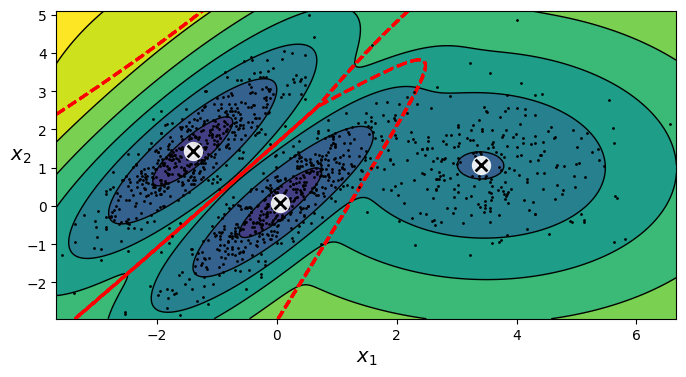

In [93]:
from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$")
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)

# save_fig("gaussian_mixtures_plot")
plt.show()

**GMM 모델 공분산 규제**

데이터셋의 차원이 크거나, 군집수가 많거나, 샘플이 적은 경우 최적의 군집화가 어려울 수 있다.
이런 경우엔 공분산 유형을 지정해서 학습을 도와줄 수 있다.
이를 위해 `covariance_type` 하이퍼파라미터를 `full` 대신 다른 값을 지정한다.
사용할 수 있는 값은 다음과 같다.
* full: 공분산에 아무런 아무런 제한 없음. 기본값으로 지정됨.
* spherical: 군집이 원형이라 가정. 지름(분산)은 다를 수 있음.
* diag: 어떤 타원형도 가능. 단. 타원의 축이 좌표축과 평행하다고 가정.
* tied: 모든 군집이 동일 모양, 동일 크기, 동일 방향을 갖는 타원형이라고 가정.

아래 왼쪽 그림은 `"tied"`를, 오른쪽 그림은 `"spherical"`을 `covariance_type`으로 지정한 결과를 보여준다.

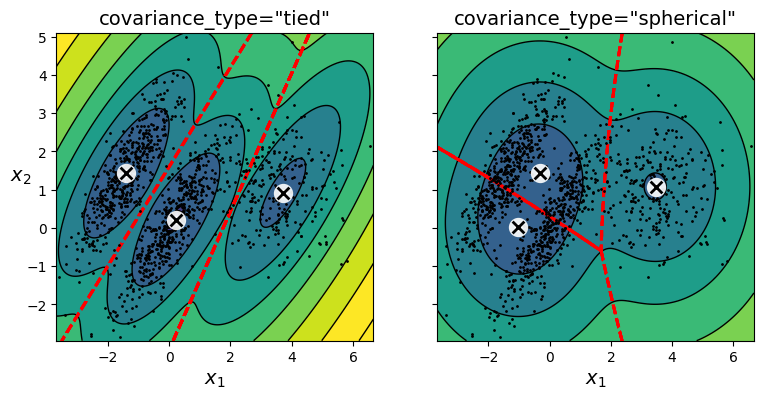

In [94]:
# extra code – this cell generates and saves Figure 9–17

gm_full = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="full", random_state=42)
gm_tied = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="tied", random_state=42)
gm_spherical = GaussianMixture(n_components=3, n_init=10,
                               covariance_type="spherical", random_state=42)
gm_diag = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="diag", random_state=42)
gm_full.fit(X)
gm_tied.fit(X)
gm_spherical.fit(X)
gm_diag.fit(X)

def compare_gaussian_mixtures(gm1, gm2, X):
    plt.figure(figsize=(9, 4))

    plt.subplot(121)
    plot_gaussian_mixture(gm1, X)
    plt.title(f'covariance_type="{gm1.covariance_type}"')

    plt.subplot(122)
    plot_gaussian_mixture(gm2, X, show_ylabels=False)
    plt.title(f'covariance_type="{gm2.covariance_type}"')

compare_gaussian_mixtures(gm_tied, gm_spherical, X)

# save_fig("covariance_type_plot")
plt.show()

아래 왼쪽 그림은 `"full"`를, 오른쪽 그림은 `"diag"`을 `covariance_type`으로 지정한 결과를 보여준다.

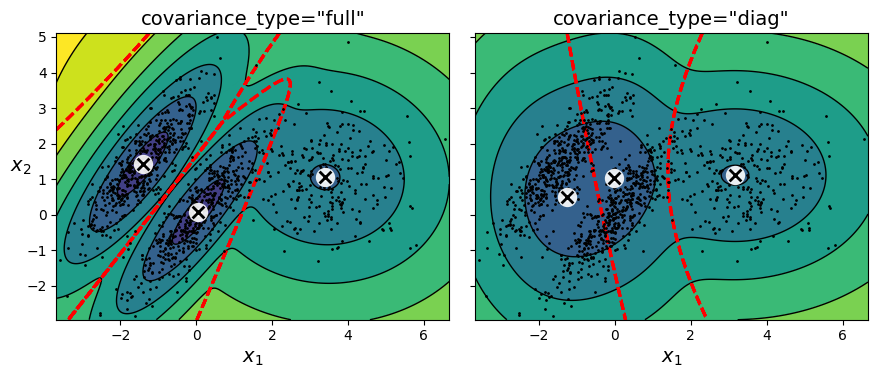

In [95]:
compare_gaussian_mixtures(gm_full, gm_diag, X)
plt.tight_layout()
plt.show()

### 9.5.2. 이상치 탐지

아래 코드는 데이터 확률 밀도가 2% 이하의 지역에 위치한 데이터 샘플을 이상치로 처리한다.

In [96]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

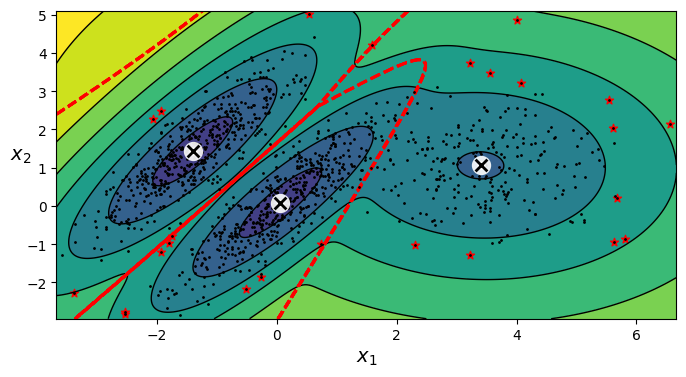

In [97]:
plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*')
plt.ylim(top=5.1)

plt.show()

### 9.5.3. 군집수 지정

아래 그림은 위 데이터셋에 대해 군집수 $k$와 AIC, BIC의 관계를 보여주며, $k=3$이 최적임을 확인해준다.

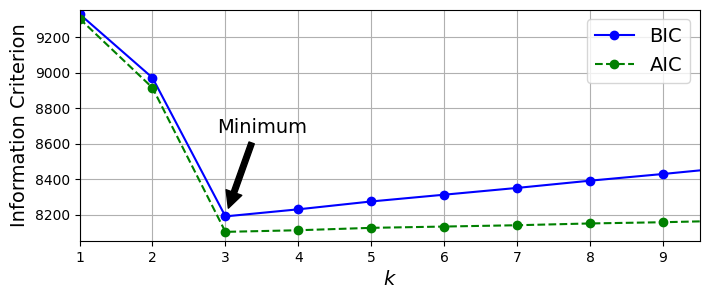

In [98]:
# extra code – this cell generates and saves Figure 9–20

gms_per_k = [GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X)
             for k in range(1, 11)]
bics = [model.bic(X) for model in gms_per_k]
aics = [model.aic(X) for model in gms_per_k]

plt.figure(figsize=(8, 3))
plt.plot(range(1, 11), bics, "bo-", label="BIC")
plt.plot(range(1, 11), aics, "go--", label="AIC")
plt.xlabel("$k$")
plt.ylabel("Information Criterion")
plt.axis([1, 9.5, min(aics) - 50, max(aics) + 50])
plt.annotate("", xy=(3, bics[2]), xytext=(3.4, 8650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(3.5, 8660, "Minimum", horizontalalignment="center")
plt.legend()
plt.grid()

plt.show()

### 9.5.4. 베이즈 가우스 혼합 모델

`BayesianGaussianMixture` 모델은 군집수를 미리 지정하지 않아도 적절한 군집수를 찾아준다.
단, `n_components` 하이퍼파라미터를 이용하여 가능한 최대 군집수를 충분히 크게 지정해줘야 한다.
그러면 훈련중에 자동으로 불필요한 군집에 0 또는 0에 매우 가까운 가중치를 지정하는 방식으로
해당 군집을 무시하도록 한다.

예를 들어 아래 코드는 최대 군집수를 10으로 지정하고 베이즈 가우스 혼합 모델을 훈련시킨다.

In [99]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)

/Users/kimdohyeon/Library/Python/3.9/lib/python/site-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)

`weights_` 속성에 저장된 군집별 가중치를 확인하면 앞서 확인한 군집별 가중치 결과와 동일하게
세 개의 군집에 대해 4:2:4 비율로 가중치를 주며 나머지 7개의 군집에 대한 가중치는 모두 0으로 처리되었다.

In [100]:
bgm.weights_.round(2)

array([0.4 , 0.21, 0.  , 0.4 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

결정 경계도 이전과 거의 동일하다.

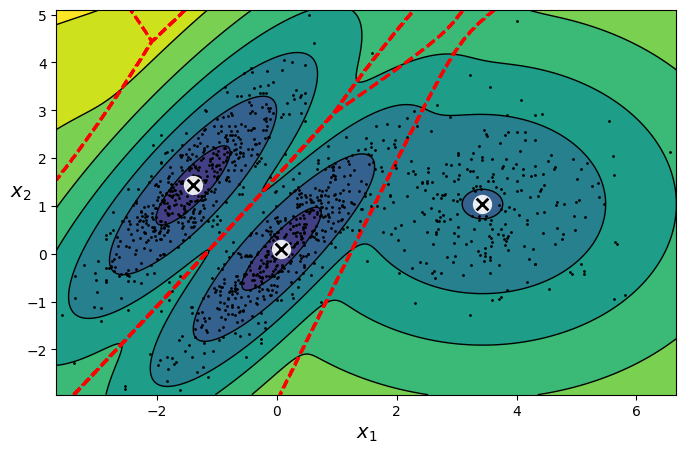

In [101]:
plt.figure(figsize=(8, 5))
plot_gaussian_mixture(bgm, X)
plt.show()

**(베이즈) 가우스 혼합 모델의 장단점**

타원형 군집으로 이뤄진 데이터셋에 대해 매우 잘 작동한다.
하지만 다른 모양을 가진 데이터셋에서는 성능이 좋지 않다.
예를 들어 초승달 데이터셋(그림 왼쪽)에 베이트 가우스 혼합 모델을 적용하면
아래 오른쪽 그림에서처럼 억지로 타원형 군집으로 맞추기 위해 필요 이상의 군집을 사용한다.

/Users/kimdohyeon/Library/Python/3.9/lib/python/site-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


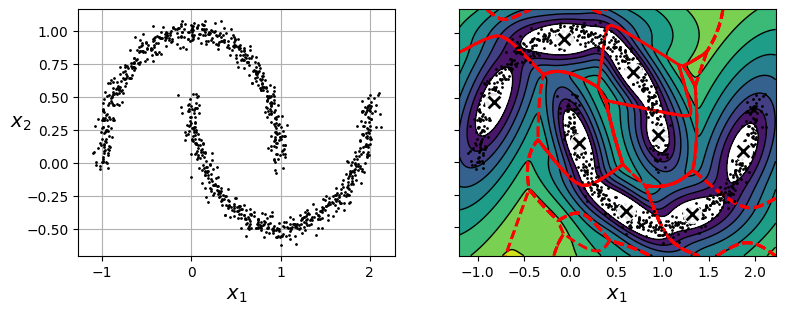

In [102]:
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_moons)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_data(X_moons)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.grid()

plt.subplot(122)
plot_gaussian_mixture(bgm, X_moons, show_ylabels=False)

plt.show()

## 연습문제

### 1. to 9.

1. In Machine Learning, clustering is the unsupervised task of grouping similar instances together. The notion of similarity depends on the task at hand: for example, in some cases two nearby instances will be considered similar, while in others similar instances may be far apart as long as they belong to the same densely packed group. Popular clustering algorithms include K-Means, DBSCAN, agglomerative clustering, BIRCH, Mean-Shift, affinity propagation, and spectral :.
2. The main applications of clustering algorithms include data analysis, customer segmentation, recommender systems, search engines, image segmentation, semi-supervised learning, dimensionality reduction, anomaly detection, and novelty detection.
3. The elbow rule is a simple technique to select the number of clusters when using K-Means: just plot the inertia (the mean squared distance from each instance to its nearest centroid) as a function of the number of clusters, and find the point in the curve where the inertia stops dropping fast (the "elbow"). This is generally close to the optimal number of clusters. Another approach is to plot the silhouette score as a function of the number of clusters. There will often be a peak, and the optimal number of clusters is generally nearby. The silhouette score is the mean silhouette coefficient over all instances. This coefficient varies from +1 for instances that are well inside their cluster and far from other clusters, to –1 for instances that are very close to another cluster. You may also plot the silhouette diagrams and perform a more thorough analysis.
4. Labeling a dataset is costly and time-consuming. Therefore, it is common to have plenty of unlabeled instances, but few labeled instances. Label propagation is a technique that consists in copying some (or all) of the labels from the labeled instances to similar unlabeled instances. This can greatly extend the number of labeled instances, and thereby allow a supervised algorithm to reach better performance (this is a form of semi-supervised learning). One approach is to use a clustering algorithm such as K-Means on all the instances, then for each cluster find the most common label or the label of the most representative instance (i.e., the one closest to the centroid) and propagate it to the unlabeled instances in the same cluster.
5. K-Means and BIRCH scale well to large datasets. DBSCAN and Mean-Shift look for regions of high density.
6. Active learning is useful whenever you have plenty of unlabeled instances but labeling is costly. In this case (which is very common), rather than randomly selecting instances to label, it is often preferable to perform active learning, where human experts interact with the learning algorithm, providing labels for specific instances when the algorithm requests them. A common approach is uncertainty sampling (see the _Active Learning_ section in chapter 9).
7. Many people use the terms _anomaly detection_ and _novelty detection_ interchangeably, but they are not exactly the same. In anomaly detection, the algorithm is trained on a dataset that may contain outliers, and the goal is typically to identify these outliers (within the training set), as well as outliers among new instances. In novelty detection, the algorithm is trained on a dataset that is presumed to be "clean," and the objective is to detect novelties strictly among new instances. Some algorithms work best for anomaly detection (e.g., Isolation Forest), while others are better suited for novelty detection (e.g., one-class SVM).
8. A Gaussian mixture model (GMM) is a probabilistic model that assumes that the instances were generated from a mixture of several Gaussian distributions whose parameters are unknown. In other words, the assumption is that the data is grouped into a finite number of clusters, each with an ellipsoidal shape (but the clusters may have different ellipsoidal shapes, sizes, orientations, and densities), and we don't know which cluster each instance belongs to. This model is useful for density estimation, clustering, and anomaly detection.
9. One way to find the right number of clusters when using a Gaussian mixture model is to plot the Bayesian information criterion (BIC) or the Akaike information criterion (AIC) as a function of the number of clusters, then choose the number of clusters that minimizes the BIC or AIC. Another technique is to use a Bayesian Gaussian mixture model, which automatically selects the number of clusters.

### 10. Cluster the Olivetti Faces Dataset

*연습: 클래식 Olivetti 얼굴 데이터세트에는 400개의 회색조 64 × 64픽셀 얼굴 이미지가 포함되어 있습니다. 각 이미지는 크기 4,096의 1D 벡터로 평면화됩니다. 40명의 서로 다른 사람들의 사진이 찍혔으며(각각 10번), 일반적인 작업은 각 사진에 어떤 사람이 나타나는지 예측할 수 있는 모델을 훈련하는 것입니다. `sklearn.datasets.fetch_olivetti_faces()` 함수를 사용하여 데이터 세트를 로드합니다.*

In [103]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/kimdohyeon/scikit_learn_data


In [104]:
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [105]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

:*연습: 그런 다음 훈련 세트, 검증 세트, 테스트 세트로 분할합니다(데이터 세트는 이미 0과 1 사이에서 조정되어 있습니다). 데이터 세트가 매우 작기 때문에 계층화된 샘플링을 사용하여 각 세트에 사람당 동일한 수의 이미지가 있는지 확인하는 것이 좋습니다.*

In [106]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(olivetti.data,
                                                   olivetti.target))
X_train_valid = olivetti.data[train_valid_idx]
y_train_valid = olivetti.target[train_valid_idx]
X_test = olivetti.data[test_idx]
y_test = olivetti.target[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=43)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X_train_valid[train_idx]
y_train = y_train_valid[train_idx]
X_valid = X_train_valid[valid_idx]
y_valid = y_train_valid[valid_idx]

In [107]:
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(280, 4096) (280,)
(80, 4096) (80,)
(40, 4096) (40,)


속도를 높이기 위해 PCA를 사용하여 데이터의 차원을 줄입니다.

In [108]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(199)

*연습: 다음으로 K-평균을 사용하여 이미지를 클러스터링하고 클러스터 수가 충분한지 확인합니다(이 장에서 설명하는 기술 중 하나 사용).*

In [109]:
from sklearn.cluster import KMeans

k_range = range(5, 150, 5)
kmeans_per_k = []
for k in k_range:
    print(f"k={k}")
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_per_k.append(kmeans)

k=5
k=10
k=15
k=20
k=25
k=30
k=35
k=40
k=45
k=50
k=55
k=60
k=65
k=70
k=75
k=80
k=85
k=90
k=95
k=100
k=105
k=110
k=115
k=120
k=125
k=130
k=135
k=140
k=145


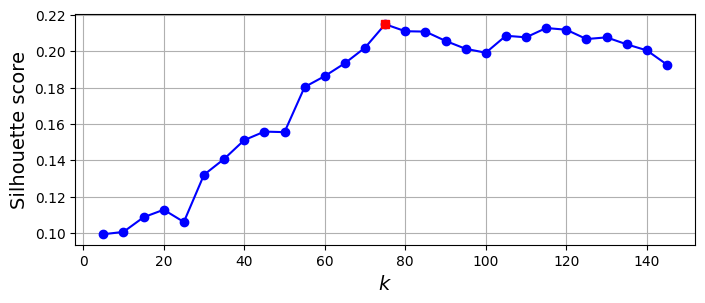

In [110]:
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_train_pca, model.labels_)
                     for model in kmeans_per_k]
best_index = np.argmax(silhouette_scores)
best_k = k_range[best_index]
best_score = silhouette_scores[best_index]

plt.figure(figsize=(8, 3))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.plot(best_k, best_score, "rs")
plt.grid()
plt.show()

In [111]:
best_k

75

가장 좋은 클러스터 수는 120으로 상당히 높은 것 같습니다. 사진에 40명의 다른 사람이 있으므로 40개일 것이라고 예상했을 수도 있습니다. 그러나 같은 사람이 사진에 따라 상당히 다르게 보일 수 있습니다(예: 안경 착용 여부, 단순히 왼쪽이나 오른쪽으로 이동).

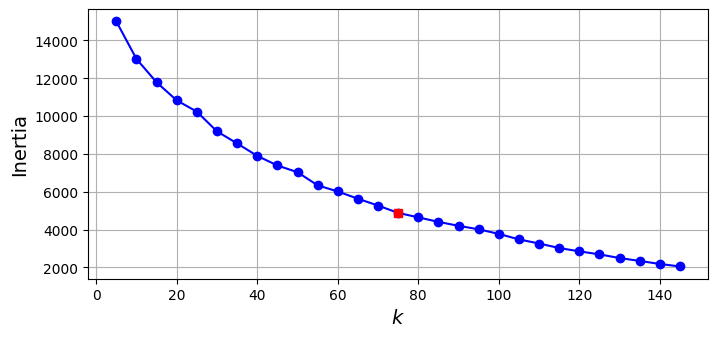

In [112]:
inertias = [model.inertia_ for model in kmeans_per_k]
best_inertia = inertias[best_index]

plt.figure(figsize=(8, 3.5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.plot(best_k, best_inertia, "rs")
plt.grid()
plt.show()

명확한 엘보가 없기 때문에 이 관성 다이어그램에서는 클러스터의 최적 개수가 명확하지 않으므로 k=120을 유지하겠습니다.

In [113]:
best_model = kmeans_per_k[best_index]

*연습: 클러스터를 시각화합니다. 각 클러스터에 비슷한 얼굴이 보입니까?*

Cluster 0


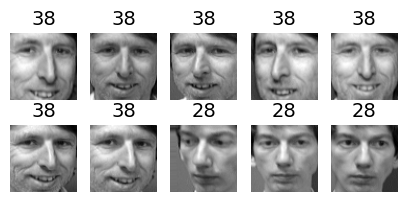

Cluster 1


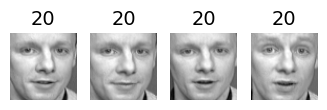

Cluster 2


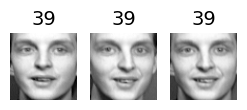

Cluster 3


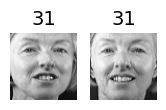

Cluster 4


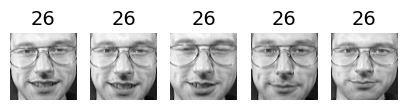

Cluster 5


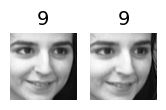

Cluster 6


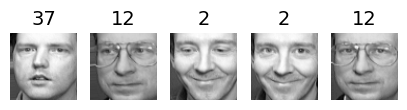

Cluster 7


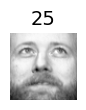

Cluster 8


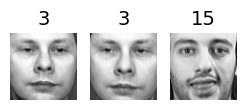

Cluster 9


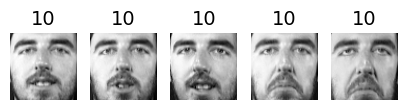

Cluster 10


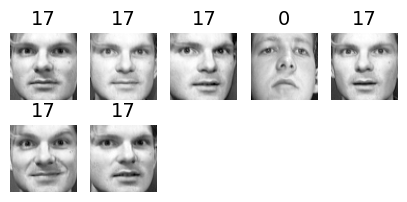

Cluster 11


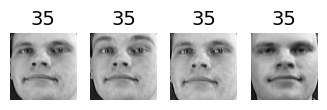

Cluster 12


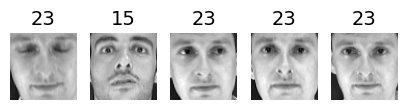

Cluster 13


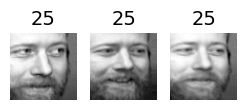

Cluster 14


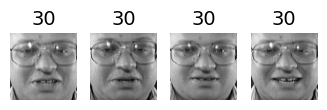

Cluster 15


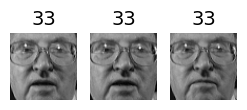

Cluster 16


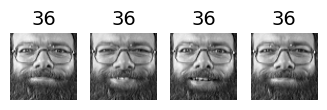

Cluster 17


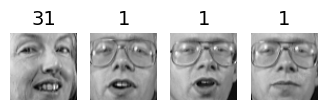

Cluster 18


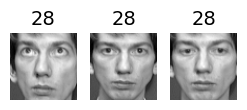

Cluster 19


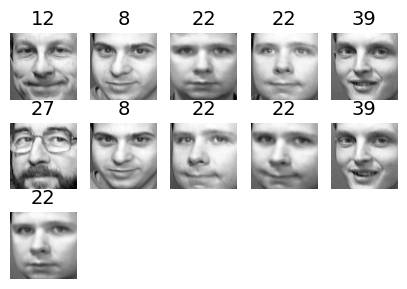

Cluster 20


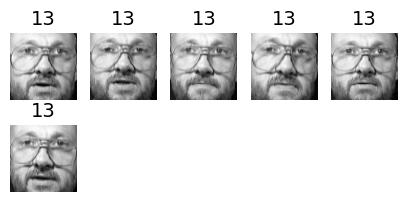

Cluster 21


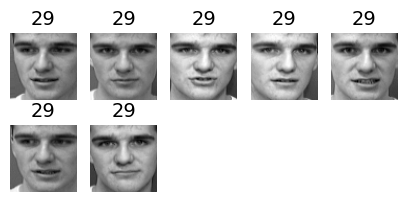

Cluster 22


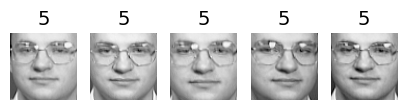

Cluster 23


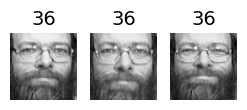

Cluster 24


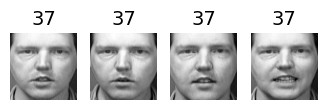

Cluster 25


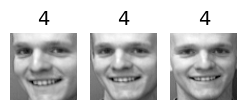

Cluster 26


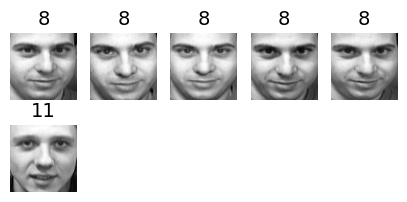

Cluster 27


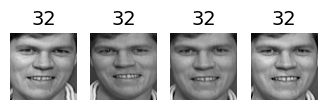

Cluster 28


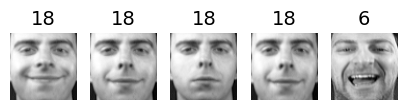

Cluster 29


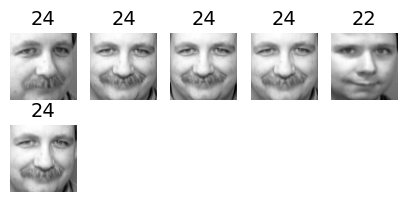

Cluster 30


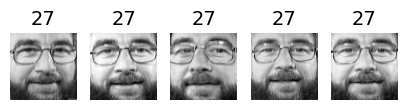

Cluster 31


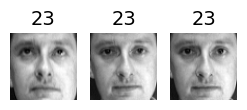

Cluster 32


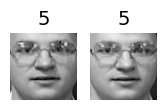

Cluster 33


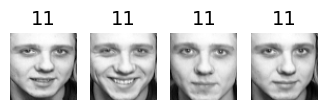

Cluster 34


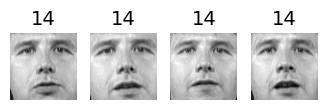

Cluster 35


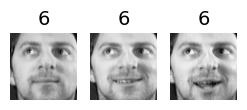

Cluster 36


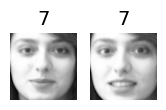

Cluster 37


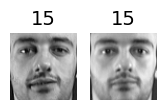

Cluster 38


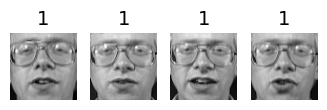

Cluster 39


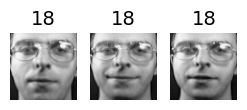

Cluster 40


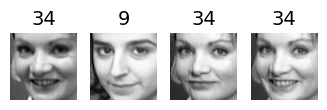

Cluster 41


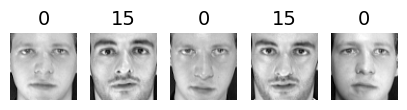

Cluster 42


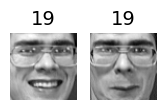

Cluster 43


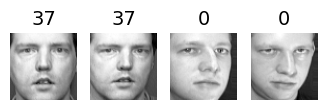

Cluster 44


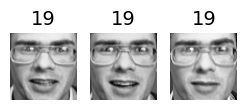

Cluster 45


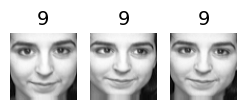

Cluster 46


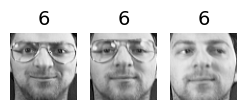

Cluster 47


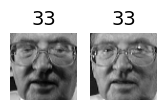

Cluster 48


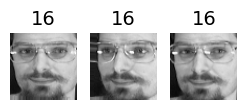

Cluster 49


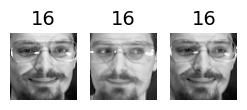

Cluster 50


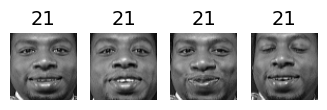

Cluster 51


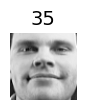

Cluster 52


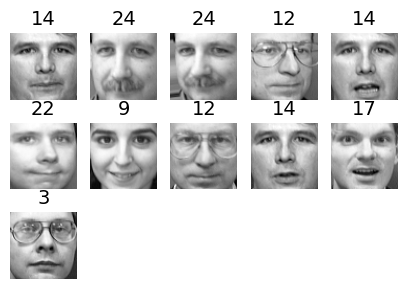

Cluster 53


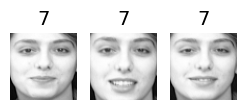

Cluster 54


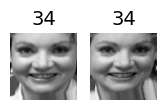

Cluster 55


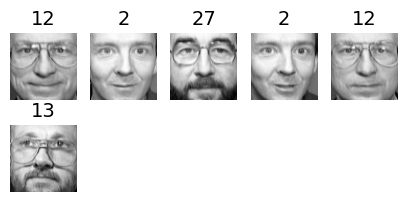

Cluster 56


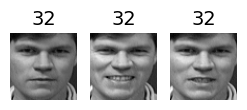

Cluster 57


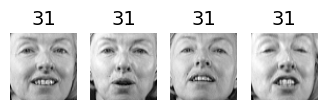

Cluster 58


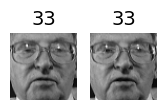

Cluster 59


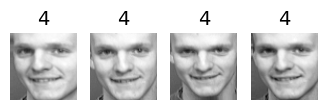

Cluster 60


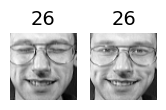

Cluster 61


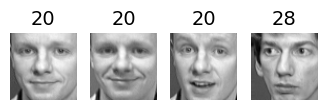

Cluster 62


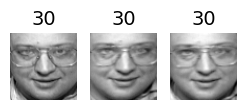

Cluster 63


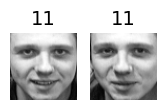

Cluster 64


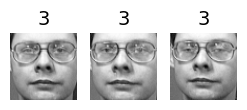

Cluster 65


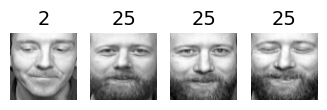

Cluster 66


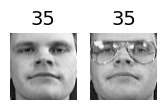

Cluster 67


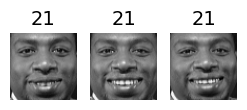

Cluster 68


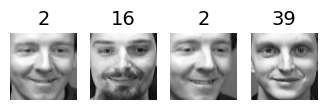

Cluster 69


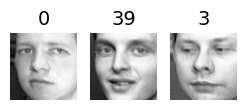

Cluster 70


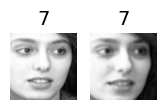

Cluster 71


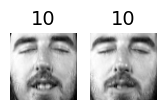

Cluster 72


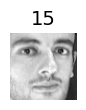

Cluster 73


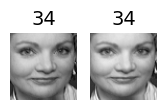

Cluster 74


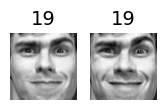

In [114]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

for cluster_id in np.unique(best_model.labels_):
    print("Cluster", cluster_id)
    in_cluster = best_model.labels_==cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

클러스터 3개 중 약 2개가 유용합니다. 즉, 모두 같은 사람의 사진이 2개 이상 포함되어 있습니다. 그러나 나머지 클러스터에는 하나 이상의 침입자가 있거나 단일 그림만 있습니다.

이러한 방식으로 이미지를 클러스터링하는 것은 모델을 교육할 때 직접적으로 유용하기에는 너무 부정확할 수 있지만(아래에서 살펴보겠지만) 새 데이터세트에서 이미지에 라벨을 지정할 때 매우 유용할 수 있습니다. 일반적으로 라벨링이 훨씬 빨라집니다.

### 11. Using Clustering as Preprocessing for Classification

*연습: 올리베티 얼굴 데이터세트를 계속 사용하여 각 사진에 어떤 사람이 나타나는지 예측하고 검증 세트에서 평가하도록 분류기를 훈련합니다.*

In [115]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_pca, y_train)
clf.score(X_valid_pca, y_valid)

0.925

*연습: 다음으로 K-Means를 차원 축소 도구로 사용하고 축소된 집합에 대해 분류기를 훈련합니다.*

In [116]:
X_train_reduced = best_model.transform(X_train_pca)
X_valid_reduced = best_model.transform(X_valid_pca)
X_test_reduced = best_model.transform(X_test_pca)

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_reduced, y_train)

clf.score(X_valid_reduced, y_valid)

0.7375

으악! 전혀 좋지 않습니다! 클러스터 수를 조정하는 것이 도움이 되는지 살펴보겠습니다.

*연습: 분류기가 최고의 성능을 얻을 수 있도록 하는 클러스터 수를 검색합니다. 어떤 성능에 도달할 수 있습니까?*

이 노트북의 앞부분에서 했던 것처럼 `GridSearchCV`를 사용할 수 있지만 이미 검증 세트가 있으므로 K-겹 교차 검증이 필요하지 않고 단일 하이퍼파라미터만 탐색하므로 더 간단합니다. 루프를 수동으로 실행하세요.

In [117]:
from sklearn.pipeline import make_pipeline

for n_clusters in k_range:
    pipeline = make_pipeline(
        KMeans(n_clusters=n_clusters, random_state=42),
        RandomForestClassifier(n_estimators=150, random_state=42)
    )
    pipeline.fit(X_train_pca, y_train)
    print(n_clusters, pipeline.score(X_valid_pca, y_valid))

5 0.4125
10 0.4375
15 0.5875
20 0.6125
25 0.6625
30 0.6625
35 0.6625
40 0.675
45 0.675
50 0.6875
55 0.75
60 0.7
65 0.725
70 0.7
75 0.7375
80 0.725
85 0.75
90 0.775
95 0.775
100 0.7625
105 0.7375
110 0.725
115 0.7625
120 0.7625
125 0.7625
130 0.725
135 0.7125
140 0.8
145 0.725


아, 클러스터 수를 조정하더라도 정확도는 80%를 넘지 못합니다. 클러스터 중심까지의 거리가 원본 이미지만큼 유익하지 않은 것 같습니다.

*연습: 축소된 세트의 특징을 원래 특징에 추가하면 어떻게 될까요(역시 최상의 클러스터 수 검색)?*

In [118]:
X_train_extended = np.c_[X_train_pca, X_train_reduced]
X_valid_extended = np.c_[X_valid_pca, X_valid_reduced]
X_test_extended = np.c_[X_test_pca, X_test_reduced]

In [119]:
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_extended, y_train)
clf.score(X_valid_extended, y_valid)

0.85

조금 나아졌지만 클러스터 기능이 없는 것보다는 여전히 나쁩니다. 이 경우 클러스터는 분류기를 직접 훈련하는 데 유용하지 않습니다(그러나 새 훈련 인스턴스에 레이블을 지정할 때는 여전히 도움이 될 수 있습니다).

### 12. A Gaussian Mixture Model for the Olivetti Faces Dataset

*연습: Olivetti 얼굴 데이터세트에서 가우스 혼합 모델을 훈련합니다. 알고리즘 속도를 높이려면 데이터세트의 차원성을 줄여야 할 수도 있습니다(예: PCA를 사용하여 분산의 99%를 보존함).*

In [120]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=40, random_state=42)
y_pred = gm.fit_predict(X_train_pca)

*연습: 모델을 사용하여 몇 가지 새로운 얼굴을 생성하고(`sample()` 메서드 사용) 이를 시각화합니다(PCA를 사용한 경우 `inverse_transform()` 메서드를 사용해야 함).*

In [121]:
n_gen_faces = 20
gen_faces_reduced, y_gen_faces = gm.sample(n_samples=n_gen_faces)
gen_faces = pca.inverse_transform(gen_faces_reduced)

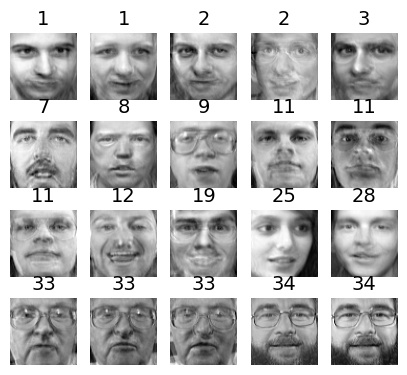

In [122]:
plot_faces(gen_faces, y_gen_faces)

*연습: 일부 이미지를 수정(예: 회전, 뒤집기, 어둡게)하고 모델이 이상을 감지할 수 있는지 확인합니다(예: 일반 이미지와 이상에 대한 `score_samples()` 메서드의 출력 비교).*

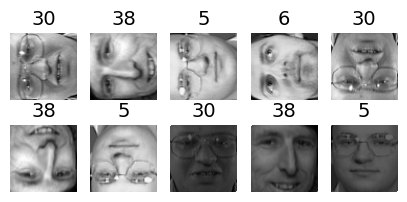

In [123]:
n_rotated = 4
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

n_flipped = 3
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

n_darkened = 3
darkened = X_train[:n_darkened].copy()
darkened[:, 1:-1] *= 0.3
y_darkened = y_train[:n_darkened]

X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

plot_faces(X_bad_faces, y_bad)

In [124]:
X_bad_faces_pca = pca.transform(X_bad_faces)

In [125]:
gm.score_samples(X_bad_faces_pca)

array([-1.85964141e+07, -1.73014586e+07, -4.15207070e+07, -4.81261011e+07,
       -3.20478666e+07, -1.35425859e+07, -2.92374968e+07, -9.25155142e+07,
       -1.03272769e+08, -5.41697159e+07])

잘못된 면은 모두 가우스 혼합 모델에서 가능성이 매우 낮은 것으로 간주됩니다. 이를 일부 교육 인스턴스의 점수와 비교하세요.

In [126]:
gm.score_samples(X_train_pca[:10])

array([1163.02020948, 1112.17307524, 1156.3213305 , 1170.67602749,
       1073.69246114, 1139.89252752, 1113.76629704, 1073.69244874,
       1048.17523011, 1048.17520895])

### 13. Using Dimensionality Reduction Techniques for Anomaly Detection

*연습: 일부 차원 축소 기술은 이상 탐지에도 사용할 수 있습니다. 예를 들어 Olivetti 얼굴 데이터세트를 가져와 PCA로 줄여서 99%의 분산을 보존합니다. 그런 다음 각 이미지의 재구성 오류를 계산합니다. 다음으로, 이전 연습에서 만든 수정된 이미지 중 일부를 가져와서 재구성 오류를 살펴보세요. 재구성 오류가 얼마나 큰지 확인하세요. 재구성된 이미지를 플롯하면 그 이유를 알 수 있습니다. 즉, 정상적인 얼굴을 재구성하려고 시도합니다.*

We already reduced the dataset using PCA earlier:

In [127]:
X_train_pca.round(2)

array([[ -3.78,   1.85,  -5.14, ...,   0.14,  -0.21,   0.06],
       [-10.15,   1.53,  -0.77, ...,  -0.12,  -0.14,  -0.02],
       [ 10.02,  -2.88,  -0.92, ...,  -0.07,  -0.  ,   0.12],
       ...,
       [ -2.48,  -2.96,   1.3 , ...,   0.02,   0.03,  -0.15],
       [  3.22,  -5.35,   1.39, ...,  -0.06,  -0.23,   0.16],
       [  0.92,   3.65,   2.26, ...,  -0.14,  -0.07,   0.06]],
      dtype=float32)

In [128]:
def reconstruction_errors(pca, X):
    X_pca = pca.transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = np.square(X_reconstructed - X).mean(axis=-1)
    return mse

In [129]:
reconstruction_errors(pca, X_train).mean()

np.float32(0.0001920535)

In [130]:
reconstruction_errors(pca, X_bad_faces).mean()

np.float32(0.004707354)

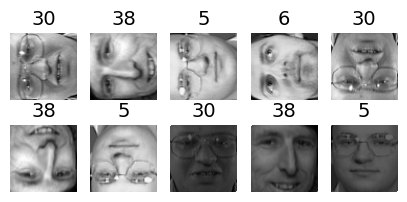

In [131]:
plot_faces(X_bad_faces, y_bad)

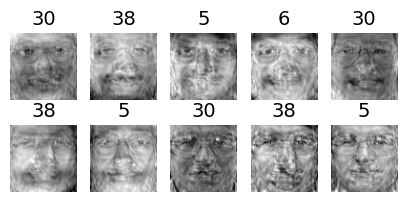

In [132]:
X_bad_faces_reconstructed = pca.inverse_transform(X_bad_faces_pca)
plot_faces(X_bad_faces_reconstructed, y_bad)